In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1D Gaussian Classification

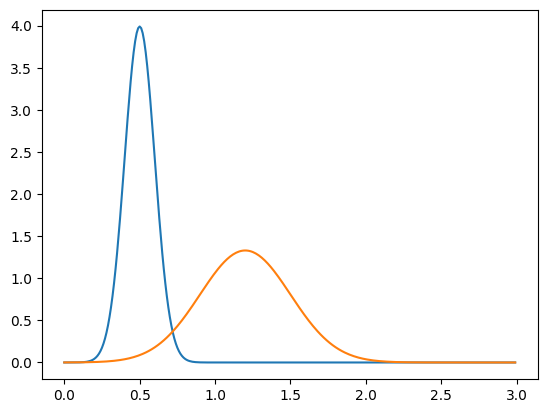

In [3]:
# based on the formulas in the lecture script 7, page 171 forward
X = np.arange(0,3,0.01)
y1 = norm.pdf(X, loc = 0.5, scale = 0.1)
y2 = norm.pdf(X, loc = 1.2, scale = 0.3)
plt.plot(X,y1, label = "bass")
plt.plot(X, y2, label = "salmon")

In [4]:
# probability of X for each y
def p_XgivenY(x, y):
    if y == -1:
        return norm.pdf(x, loc=0.5, scale=0.1) # set according to data!
    elif y == 1:
        return norm.pdf(x, loc=1.2, scale=0.3)
    else:
        return 0

In [5]:
# define marginal distributions
def p_Y(y):
    if y == -1:
        return 0.7    # set according to data!
    elif y == 1:
        return 0.3
    else:
        return 0

In [6]:
# joint distribution
def p_XY(x, y):
    return p_XgivenY(x, y) * p_Y(y)

In [7]:
# marginal distribution
def p_X(x):
    return p_XY(x, -1) + p_XY(x, 1)

In [8]:
# conditional distribution / bayes theorem
def p_YgivenX(x, y):
    return p_XY(x, y) / p_X(x)

## Visualizations

In [9]:
## plot range: [0, 3]
x = np.linspace(0, 3, 1001)

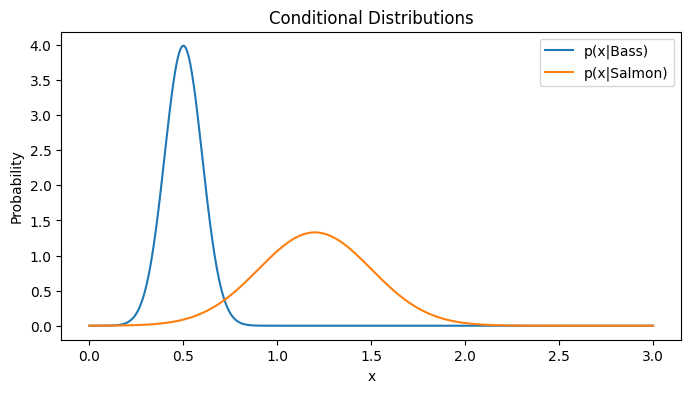

In [14]:
## the two conditional distributions p_X|Y
y1 = p_XgivenY(x, -1)
y2 = p_XgivenY(x, 1)

fig = plt.figure(figsize=(8, 4))
plt.plot(x, y1, label = "p(x|Bass)")
plt.plot(x, y2, label = "p(x|Salmon)")
plt.xlabel('x')
plt.ylabel('Probability')
plt.title('Conditional Distributions')
plt.legend()
plt.show()

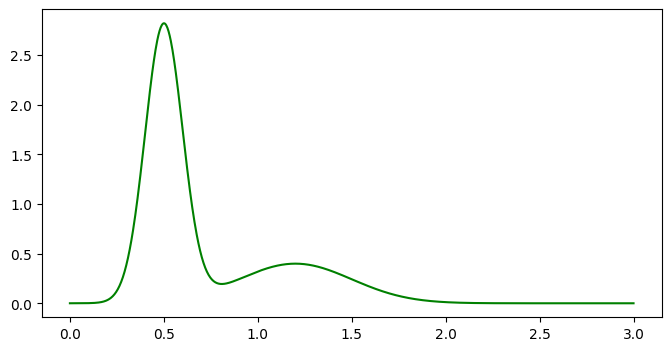

In [15]:
# the marginal distribution p_X
y3 = p_X(x)

fig = plt.figure(figsize=(8, 4))
plt.plot(x, y3, 'green')
plt.show()

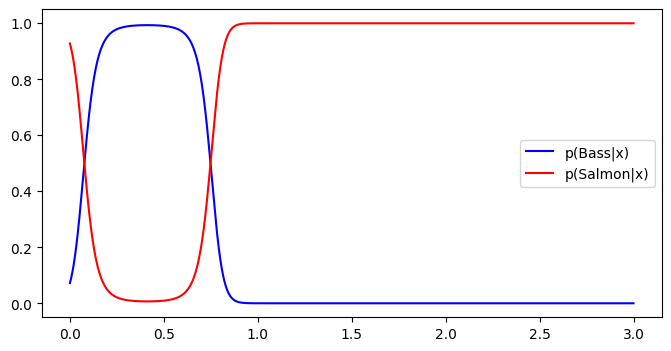

In [16]:
## the two conditional distributions p_Y|X
y4 = p_YgivenX(x, -1)
y5 = p_YgivenX(x, 1)

fig = plt.figure(figsize=(8, 4))
plt.plot(x, y4, 'blue', label="p(Bass|x)")
plt.plot(x, y5, 'red', label="p(Salmon|x)")
plt.legend()
plt.show()

# Naive Bayes

In [17]:
df_golf = pd.read_csv("play_golf.csv")
df_golf

,OUTLOOK,TEMPERATURE,HUMIDITY,WINDY,PLAY GOLF
0,Rainy,Hot,High,False,No
1,Rainy,Hot,High,True,No
2,Overcast,Hot,High,False,Yes
3,Sunny,Mild,High,False,Yes
4,Sunny,Cool,Normal,False,Yes
5,Sunny,Cool,Normal,True,No
6,Overcast,Cool,Normal,True,Yes
7,Rainy,Mild,High,False,No
8,Rainy,Cool,Normal,False,Yes
9,Sunny,Mild,Normal,False,Yes


In [18]:
CLASS_PRIORS = {}                               # P(Y)
LIKELIHOODS = {}                                # P(Xi | Y)
ALL_CLASSES = []                                # List of all unique class labels
ALL_FEATURES = []                               # List of all feature names

def train_model(df, feature_column_names, target_column_name):
    global CLASS_PRIORS, LIKELIHOODS, ALL_CLASSES, ALL_FEATURES

    y_train = df[target_column_name]
    X_train = df[feature_column_names]

    ALL_CLASSES[:] = y_train.unique().tolist()
    ALL_FEATURES[:] = feature_column_names

    n_samples = len(y_train)

    # Calculate class priors P(Y)
    for cls in ALL_CLASSES:
        CLASS_PRIORS[cls] = np.sum(y_train == cls) / n_samples

    # Calculate likelihoods P(Xi | Y)
    for feature in ALL_FEATURES:
        LIKELIHOODS[feature] = {}
        for cls in ALL_CLASSES:
            LIKELIHOODS[feature][cls] = {}
            
            # Filter all samples for ONE class
            X_cls = X_train[y_train == cls]
            n_cls_samples = len(X_cls)

            # Calculate P(value | class) for each unique value in the feature
            for value in X_train[feature].unique():
                count = np.sum(X_cls[feature] == value)
                LIKELIHOODS[feature][cls][value] = count / n_cls_samples

def p_Y(y_val):
    return CLASS_PRIORS[y_val]

def p_XgivenY(x_sample_dict, y_val):
    prob_product = 1.0 # Using product of probabilities
    for feature, value in x_sample_dict.items():
        # Get P(feature_value | y_val)
        feature_likelihood = LIKELIHOODS[feature][y_val][value]
        prob_product *= feature_likelihood

    return prob_product

def p_XY(x_sample_dict, y_val):
    # P(X,Y) = P(X|Y) * P(Y) - how likely is a certain X and Y at the same time?
    return p_XgivenY(x_sample_dict, y_val) * p_Y(y_val)

def p_X(x_sample_dict):
    # P(X) = sum probabilities over all y
    total_prob_X = 0.0
    for cls in ALL_CLASSES:
        total_prob_X += p_XY(x_sample_dict, cls)
    return total_prob_X

def p_YgivenX(x_sample_dict, y_val):
    # P(Y|X) = P(X,Y) / P(X)
    prob_xy = p_XY(x_sample_dict, y_val)
    prob_x = p_X(x_sample_dict)

    return prob_xy / prob_x

# predict posterior probability for one sample
def predict_NB(x_sample_dict):
    posteriors = {}

    # Not stricly necessary here - only 2 classes, so p(y1) = 1 - p(y0)
    for cls in ALL_CLASSES:
        posteriors[cls] = p_YgivenX(x_sample_dict, cls)
    
    # Return the class with the highest posterior probability
    best_class = None
    max_prob = -1.0
    for cls, prob in posteriors.items():
        if prob > max_prob:
            max_prob = prob
            best_class = cls
            
    return best_class

# Define feature columns and target column
feature_cols = df_golf.columns.values[:-1]
target_col = "PLAY GOLF"

# "Train" the model (populate probability structures)
train_model(df_golf, feature_cols, target_col)

print(f"Classes: {ALL_CLASSES}")
print(f"Features: {ALL_FEATURES}")

Classes: ['No', 'Yes']
Features: ['OUTLOOK', 'TEMPERATURE', 'HUMIDITY', 'WINDY']


## Usage

In [19]:
def print_probabilities(sample_data):
    for cls in ALL_CLASSES:
        print(f"  P(Y='{cls}') = {p_Y(cls):.4f}")
        print(f"  P(X|Y='{cls}') = {p_XgivenY(sample_data, cls):.4f}")
        print(f"  P(X,Y='{cls}') = {p_XY(sample_data, cls):.4f}")
    print(f"  P(X) = {p_X(sample_data):.4f}")
    for cls in ALL_CLASSES:
        print(f"  P(Y='{cls}'|X) = {p_YgivenX(sample_data, cls):.4f}")

In [20]:
# Example 1: A sample from the dataset
sample1_data = df_golf.loc[0,feature_cols].to_dict()
actual1_label = df_golf.loc[0,target_col]
print(f"Sample 1: {sample1_data}")
print(f"Actual label: {actual1_label}")

print_probabilities(sample1_data)

prediction1 = predict_NB(sample1_data)
print(f"Predicted class for Sample 1: {prediction1}")

Sample 1: {'OUTLOOK': 'Rainy', 'TEMPERATURE': 'Hot', 'HUMIDITY': 'High', 'WINDY': False}
Actual label: No
  P(Y='No') = 0.3571
  P(X|Y='No') = 0.0768
  P(X,Y='No') = 0.0274
  P(Y='Yes') = 0.6429
  P(X|Y='Yes') = 0.0110
  P(X,Y='Yes') = 0.0071
  P(X) = 0.0345
  P(Y='No'|X) = 0.7954
  P(Y='Yes'|X) = 0.2046
Predicted class for Sample 1: No


In [21]:
# Example 2: A new unseen sample
# Outlook=Sunny, Temperature=Cool, Humidity=High, Windy=True
# This is Day 14 from the original table, which results in Play Golf = No
new_sample = {'OUTLOOK': 'Sunny', 'TEMPERATURE': 'Cool', 'HUMIDITY': 'High', 'WINDY': True}

print_probabilities(new_sample)

prediction_new = predict_NB(new_sample)
print(f"Predicted class for New Sample: {prediction_new}")

  P(Y='No') = 0.3571
  P(X|Y='No') = 0.0384
  P(X,Y='No') = 0.0137
  P(Y='Yes') = 0.6429
  P(X|Y='Yes') = 0.0123
  P(X,Y='Yes') = 0.0079
  P(X) = 0.0217
  P(Y='No'|X) = 0.6334
  P(Y='Yes'|X) = 0.3666
Predicted class for New Sample: No


In [22]:
# Predict all instances in the training data
print("\nPredictions on the training data:")
correct_predictions = 0
for i in range(len(df_golf)):
    current_sample = df_golf[feature_cols].iloc[i].to_dict()
    actual_label = df_golf[target_col].iloc[i]
    predicted_label = predict_NB(current_sample)
    print(f"  Actual: {actual_label}, Predicted: {predicted_label}")
    if actual_label == predicted_label:
        correct_predictions +=1
accuracy = correct_predictions / len(df_golf)
print(f"Accuracy on training data: {accuracy:.2f}")


Predictions on the training data:
  Actual: No, Predicted: No
  Actual: No, Predicted: No
  Actual: Yes, Predicted: Yes
  Actual: Yes, Predicted: Yes
  Actual: Yes, Predicted: Yes
  Actual: No, Predicted: Yes
  Actual: Yes, Predicted: Yes
  Actual: No, Predicted: No
  Actual: Yes, Predicted: Yes
  Actual: Yes, Predicted: Yes
  Actual: Yes, Predicted: Yes
  Actual: Yes, Predicted: Yes
  Actual: Yes, Predicted: Yes
  Actual: No, Predicted: No
Accuracy on training data: 0.93


We can of course also display all the individual probabilities:

In [23]:
CLASS_PRIORS

{'No': np.float64(0.35714285714285715), 'Yes': np.float64(0.6428571428571429)}

In [24]:
LIKELIHOODS

{'OUTLOOK': {'No': {'Rainy': np.float64(0.6),
   'Overcast': np.float64(0.0),
   'Sunny': np.float64(0.4)},
  'Yes': {'Rainy': np.float64(0.2222222222222222),
   'Overcast': np.float64(0.4444444444444444),
   'Sunny': np.float64(0.3333333333333333)}},
 'TEMPERATURE': {'No': {'Hot': np.float64(0.4),
   'Mild': np.float64(0.4),
   'Cool': np.float64(0.2)},
  'Yes': {'Hot': np.float64(0.2222222222222222),
   'Mild': np.float64(0.4444444444444444),
   'Cool': np.float64(0.3333333333333333)}},
 'HUMIDITY': {'No': {'High': np.float64(0.8), 'Normal': np.float64(0.2)},
  'Yes': {'High': np.float64(0.3333333333333333),
   'Normal': np.float64(0.6666666666666666)}},
 'WINDY': {'No': {np.False_: np.float64(0.4), np.True_: np.float64(0.6)},
  'Yes': {np.False_: np.float64(0.6666666666666666),
   np.True_: np.float64(0.3333333333333333)}}}